In [10]:
import geopandas as gpd
import pandas as pd
import fiona
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [11]:
# Path
gpkg_file = '../../data/raw/germany/regions/vg250-ew_12-31.utm32s.gpkg.ebenen/vg250-ew_ebenen_1231/DE_VG250.gpkg'  

# import shapefiles of accidents
shapefile_folder = '../../data/raw/germany/collisions/shp'  # path to shape file


# load gpkg
gdf = gpd.read_file(gpkg_file)

print(gdf.head(0))


Empty GeoDataFrame
Columns: [OBJID, BEGINN, ADE, GF, BSG, ARS, AGS, SDV_ARS, GEN, BEZ, IBZ, BEM, NBD, SN_L, SN_R, SN_K, SN_V1, SN_V2, SN_G, FK_S3, NUTS, ARS_0, AGS_0, WSK, EWZ, KFL, DLM_ID, geometry]
Index: []

[0 rows x 28 columns]


/opt/anaconda3/envs/new_Bachelorarbeit/lib/python3.12/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'DE_VG250.gpkg': 'vg250_vwg' (default), 'vg250_sta', 'vg250_rbz', 'vg250_pk', 'vg250_li', 'vg250_lan', 'vg250_krs', 'vg250_gem', 'v_vg250_gem', 'v_vg250_vwg', 'v_vg250_krs', 'v_vg250_rbz', 'v_vg250_lan', 'v_vg250_sta', 'v_vg250_li', 'v_vg250_pk', 'v_vg250_f', 'v_vz250_gem', 'vgtb_vz_gem', 'vgtb_rgs_vg', 'vgtb_rgs_otl', 'vgtb_azb_vg', 'vg_werte', 'vg_ibz', 'vg_daten', 'v_at_vg', 'v_vgtb_att_vg', 'v_vgtb_azb_vg', 'v_vgtb_rgs_vg', 'v_vgtb_rgs_otl', 'v_vg_ibz', 'v_vg_sn_zahl', 'v_werte_agz', 'v_werte_rdg', 'v_werte_gm5', 'v_werte_gmk', 'v_werte_ade', 'v_werte_gf', 'v_werte_bsg', 'v_werte_nbd', 'v_werte_fks3', 'v_werte_spr'. Specify layer parameter to avoid this warning.
  result = read_func(


In [12]:
# layers
layer_names = fiona.listlayers(gpkg_file)
print(layer_names)

# layer with 'Gemeinden' (documentation)
gdf_layer = gpd.read_file(gpkg_file, layer='vg250_gem') 

['vg250_vwg', 'vg250_sta', 'vg250_rbz', 'vg250_pk', 'vg250_li', 'vg250_lan', 'vg250_krs', 'vg250_gem', 'v_vg250_gem', 'v_vg250_vwg', 'v_vg250_krs', 'v_vg250_rbz', 'v_vg250_lan', 'v_vg250_sta', 'v_vg250_li', 'v_vg250_pk', 'v_vg250_f', 'v_vz250_gem', 'vgtb_vz_gem', 'vgtb_rgs_vg', 'vgtb_rgs_otl', 'vgtb_azb_vg', 'vg_werte', 'vg_ibz', 'vg_daten', 'v_at_vg', 'v_vgtb_att_vg', 'v_vgtb_azb_vg', 'v_vgtb_rgs_vg', 'v_vgtb_rgs_otl', 'v_vg_ibz', 'v_vg_sn_zahl', 'v_werte_agz', 'v_werte_rdg', 'v_werte_gm5', 'v_werte_gmk', 'v_werte_ade', 'v_werte_gf', 'v_werte_bsg', 'v_werte_nbd', 'v_werte_fks3', 'v_werte_spr']


<Axes: >

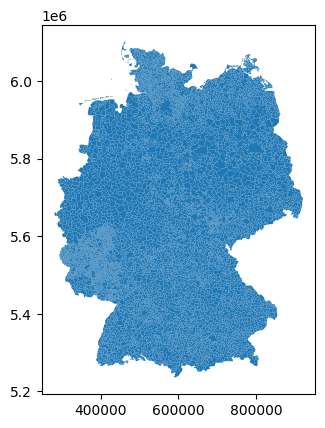

In [13]:
gdf_layer.plot()

In [14]:
#filter 'Gemeinden' with more than 10000 Citizen -> defined as Urban in the UK collisions dataset
urban_region_gdf = gdf_layer[gdf_layer['EWZ'] >= 10000]
print(urban_region_gdf)

rural_regions = gdf_layer[gdf_layer['EWZ'] < 10000]

                  OBJID     BEGINN  ADE  GF  BSG           ARS       AGS  \
0      DEBKGVG200000008 2022-12-20    6   4    1  010010000000  01001000   
1      DEBKGVG200000009 2022-12-20    6   4    1  010020000000  01002000   
2      DEBKGVG20000000A 2023-10-04    6   4    1  010030000000  01003000   
3      DEBKGVG20000000B 2022-12-20    6   4    1  010040000000  01004000   
4      DEBKGVG20000000C 2023-10-04    6   4    1  010510011011  01051011   
...                 ...        ...  ...  ..  ...           ...       ...   
10906  DEBKGVG2000008FD 2023-10-04    6   4    1  160760022022  16076022   
10945  DEBKGVG2000008GH 2023-10-04    6   4    1  160765054087  16076087   
10948  DEBKGVG2000008GL 2022-12-20    6   4    1  160770001001  16077001   
10950  DEBKGVG2000008GN 2022-12-20    6   4    1  160770032032  16077032   
10977  DEBKGVG2000008HE 2023-04-26    6   4    1  160775052043  16077043   

            SDV_ARS                 GEN    BEZ  ...  SN_G FK_S3   NUTS  \
0      010010

EPSG:25832
0        MULTIPOLYGON (((526513.753 6075133.412, 526547...
1        MULTIPOLYGON (((575841.569 6032148.032, 575869...
2        MULTIPOLYGON (((623056.151 5983746.445, 623191...
3        MULTIPOLYGON (((565015.652 6000637.513, 565128...
4        MULTIPOLYGON (((510789.928 5977425.102, 510965...
                               ...                        
10906    MULTIPOLYGON (((723826.667 5622362.805, 724207...
10945    MULTIPOLYGON (((714107.169 5622303.283, 714303...
10948    MULTIPOLYGON (((739465.735 5659092.913, 739502...
10950    MULTIPOLYGON (((737718.612 5664623.111, 737892...
10977    MULTIPOLYGON (((737649.246 5650106.086, 737999...
Name: geometry, Length: 1626, dtype: geometry


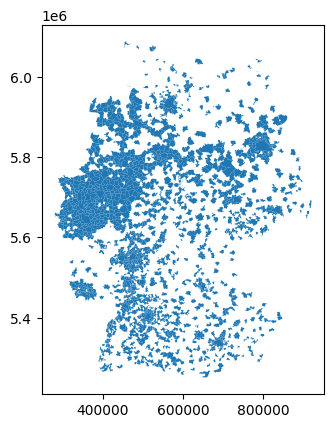

In [15]:
#print(gdf_layer.info())

urban_region_gdf.plot()
print(urban_region_gdf.crs)
print(urban_region_gdf.geometry)



In [16]:
# lost of shape files for the case there is more than one
shapefiles = [f for f in os.listdir(shapefile_folder) if f.endswith('.shp')]
#print(len(shapefiles))

# chose first shapefile
collision_shapefile = shapefiles[0] 
collision_gdf = gpd.read_file(os.path.join(shapefile_folder, collision_shapefile))

# collisions in urban regions
collisions_in_urban_regions = gpd.sjoin(collision_gdf, urban_region_gdf, predicate="intersects")

/opt/anaconda3/envs/new_Bachelorarbeit/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'PointM' is converted to 'Point'
  return ogr_read(


In [17]:
collsions_urban= collisions_in_urban_regions.shape[0]
print(collsions_urban)
all_collisions = collision_gdf.shape[0]
print()
collisions_rural = all_collisions-collsions_urban
print(collisions_rural)

206756

61763


FileNotFoundError: [Errno 2] No such file or directory: '../../results/plots_urban_or_rural_area/collisions_urban_or_rural_area.png'

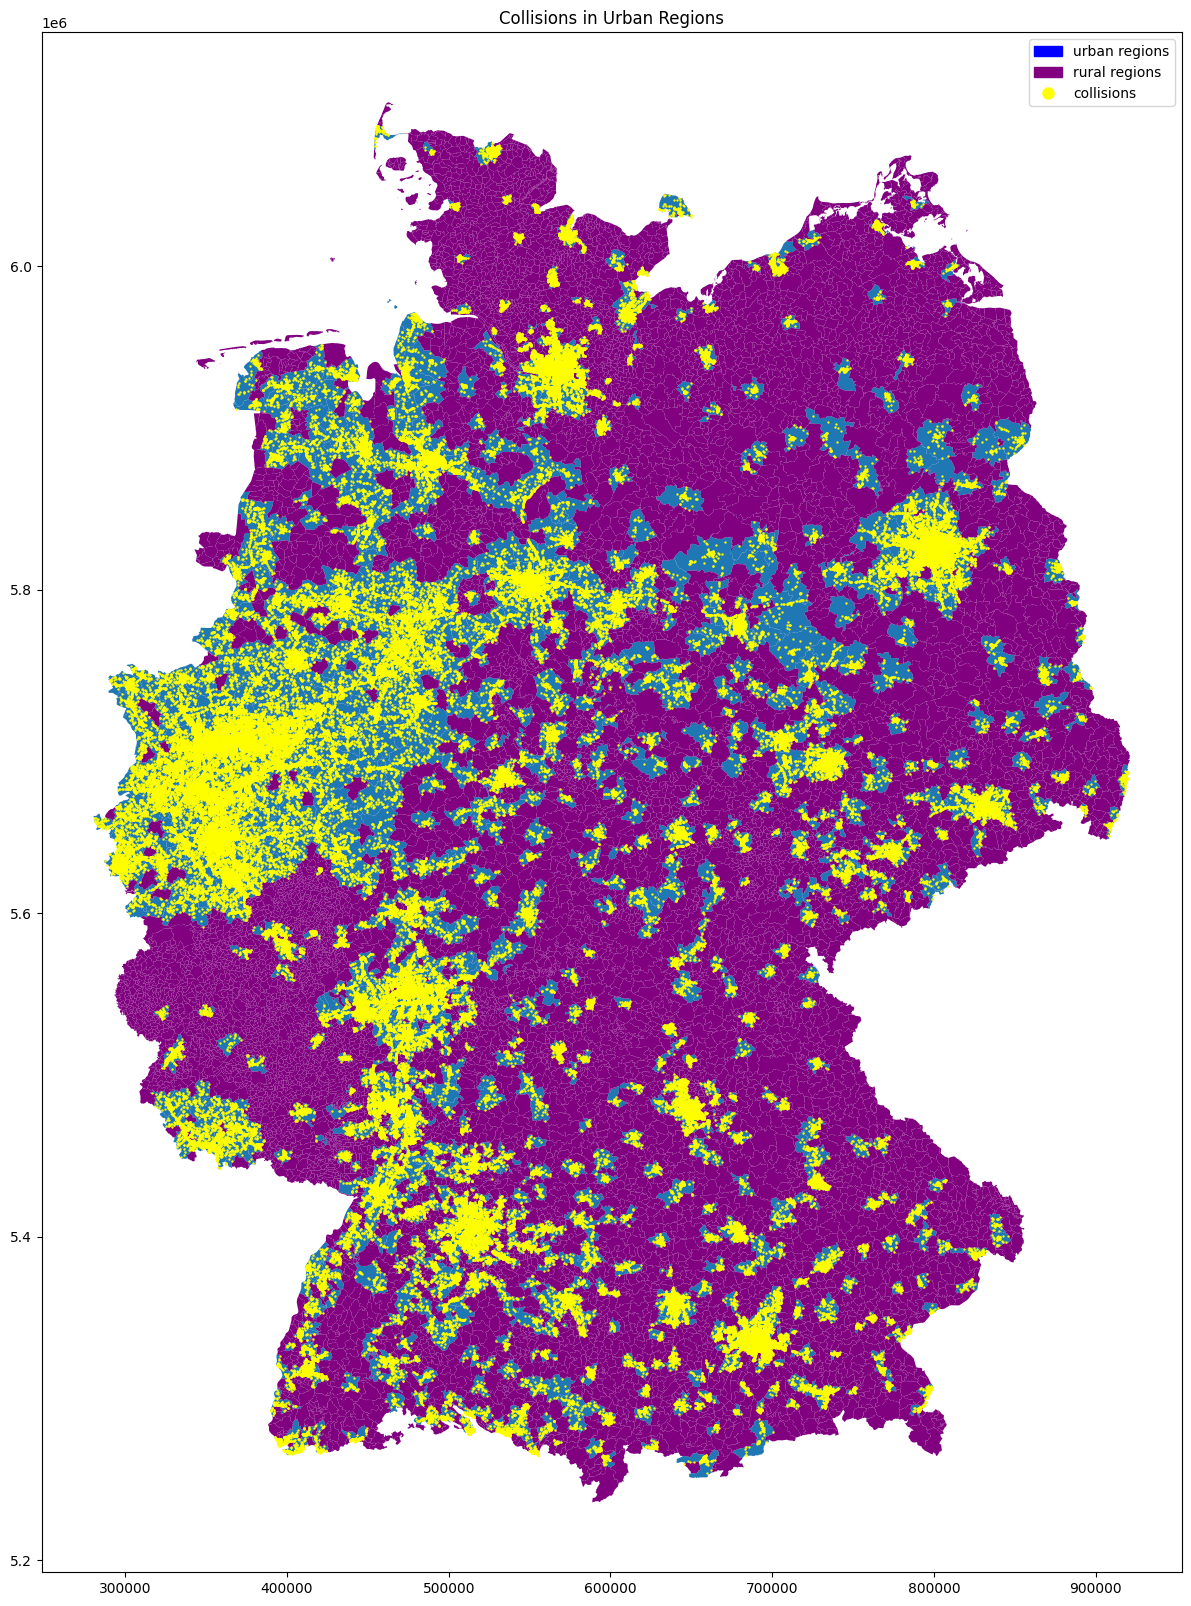

In [18]:
#urban regions
ax = urban_region_gdf.plot( figsize=(20, 20),label='urban regions')

#rural regions
rural_regions.plot(color='purple', ax=ax, label='rural regions')

#collisions
collisions_in_urban_regions.plot(markersize=0.5, color='yellow', ax=ax, label='urban collisions')

plt.title('Collisions in Urban Regions')

# legende
legend_patches = [
    mpatches.Patch(color='blue', label='urban regions'),
    mpatches.Patch(color='purple', label='rural regions'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='collisions')
    ]

ax.legend(handles=legend_patches, loc='upper right')

plt.savefig('../../results/plots_urban_or_rural_area/collisions_urban_or_rural_area.png') 
plt.show()

In [ ]:
collisions_urban = collisions_in_urban_regions.drop(columns='geometry')
collisions_urban.rename(columns={'UIDENTSTLA': 'c_id'}, inplace=True)
collisions_urban.to_csv('../../data/preprocessed/germany/collisions/intermediate_steps/collisions_urban_area_ger.csv', index=True)
collisions_urban


,c_id,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,UKATEGORIE,...,SN_V2,SN_G,FK_S3,NUTS,ARS_0,AGS_0,WSK,EWZ,KFL,DLM_ID
4,01240525171013522024,01,0,60,004,2024,05,19,7,3,...,04,004,R,DEF0D,010600004004,01060004,2009-01-01,15451,24.14,DEBKGDL20000DYUR
5,01240525161013252024,01,0,62,004,2024,05,14,7,3,...,04,004,R,DEF0F,010620004004,01062004,2009-01-01,25104,52.59,DEBKGDL20000E1VI
6,01240525152013982024,01,0,03,000,2024,05,01,7,3,...,00,000,R,DEF03,010030000000,01003000,2006-02-01,219044,214.19,DEBKGDL20000DYMA
7,01240525152013802024,01,0,03,000,2024,05,08,7,3,...,00,000,R,DEF03,010030000000,01003000,2006-02-01,219044,214.19,DEBKGDL20000DYMA
8,01240525152013292024,01,0,03,000,2024,05,15,7,3,...,00,000,R,DEF03,010030000000,01003000,2006-02-01,219044,214.19,DEBKGDL20000DYMA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268514,10240927009432524520,10,0,42,116,2024,09,17,6,2,...,16,116,R,DEC02,100420116116,10042116,2009-01-01,15860,111.22,DEBKGDL20000E0ES
268515,10240927009522524460,10,0,45,114,2024,09,15,6,3,...,14,114,R,DEC05,100450114114,10045114,2009-01-01,42498,82.61,DEBKGDL20000E119
268516,10241001009422500650,10,0,42,114,2024,10,14,3,2,...,14,114,R,DEC02,100420114114,10042114,2009-01-01,12087,78.19,DEBKGDL20000E0JK
268517,10241011009422509150,10,0,42,115,2024,10,13,6,3,...,14,114,R,DEC02,100420114114,10042114,2009-01-01,12087,78.19,DEBKGDL20000E0JK
